# Analyzing your results

A sweep hands you a labeled `xarray.Dataset`, so the analysis every experiment
needs is a one-liner on named dimensions — not manual bookkeeping over run
directories. This notebook runs a tiny `lr × seed` sweep with `@mushin.sweep`,
then walks the moves you'll repeat on *every* result: reduce over seeds, pick
the best config, slice, tabulate, plot, and save/reload.

In [ ]:
import tempfile

import mushin


@mushin.sweep
def experiment(lr, seed):
    # A toy metric (no training needed) so we can focus on the analysis: a smooth
    # accuracy surface that peaks near lr=0.1, plus a little seeded per-seed noise.
    import math
    import random

    base = 1.0 - (math.log10(lr) + 1.0) ** 2 / 4  # peaks at lr=0.1
    noise = 0.02 * (random.Random(seed).random() - 0.5)
    return dict(accuracy=max(0.0, min(1.0, base + noise)))


ds = experiment.run(
    lr=mushin.multirun([0.01, 0.1, 1.0]),
    seed=mushin.multirun([0, 1, 2, 3]),
    working_dir=tempfile.mkdtemp(),
)
ds

[2026-07-20 22:48:18,306][HYDRA] Launching 12 jobs locally


[2026-07-20 22:48:18,306][HYDRA] 	#0 : +lr=0.01 +seed=0


[2026-07-20 22:48:18,350][HYDRA] 	#1 : +lr=0.01 +seed=1


[2026-07-20 22:48:18,392][HYDRA] 	#2 : +lr=0.01 +seed=2


[2026-07-20 22:48:18,435][HYDRA] 	#3 : +lr=0.01 +seed=3


...

[2026-07-20 22:48:18,686][HYDRA] 	#8 : +lr=1.0 +seed=0


[2026-07-20 22:48:18,729][HYDRA] 	#9 : +lr=1.0 +seed=1


[2026-07-20 22:48:18,774][HYDRA] 	#10 : +lr=1.0 +seed=2


[2026-07-20 22:48:18,816][HYDRA] 	#11 : +lr=1.0 +seed=3


<xarray.Dataset> Size: 152B
Dimensions:   (lr: 3, seed: 4)
Coordinates:
  * lr        (lr) float64 24B 0.01 0.1 1.0
  * seed      (seed) int64 32B 0 1 2 3
Data variables:
    accuracy  (lr, seed) float64 96B 0.7569 0.7427 0.7591 ... 0.7591 0.7448
Attributes:
    provenance:  {"timestamp": "2026-07-21T02:48:18.348997+00:00", "python": ...

The result is fully labeled — dims `(lr, seed)`, one data variable `accuracy`.
Everything below operates on those names.

## Reduce over seeds

The most common move: collapse the `seed` dimension to a mean (and its spread).

In [ ]:
mean_acc = ds["accuracy"].mean("seed")
std_acc = ds["accuracy"].std("seed")
mean_acc

<xarray.DataArray 'accuracy' (lr: 3)> Size: 24B
array([0.75086392, 0.99686164, 0.75086392])
Coordinates:
  * lr       (lr) float64 24B 0.01 0.1 1.0

## Pick the best configuration

`idxmax` returns the coordinate *label* (the learning rate), not a bare index —
so you get the answer you actually want.

In [ ]:
best_lr = float(mean_acc.idxmax("lr"))
print(f"best lr = {best_lr}  (mean accuracy {float(mean_acc.max()):.3f})")

best lr = 0.1  (mean accuracy 0.997)


## Slice and filter

Select by label with `.sel(...)` — here, every seed's accuracy at one lr.

In [ ]:
ds["accuracy"].sel(lr=0.1)

<xarray.DataArray 'accuracy' (seed: 4)> Size: 32B
array([1.        , 0.99268728, 1.        , 0.99475929])
Coordinates:
    lr       float64 8B 0.1
  * seed     (seed) int64 32B 0 1 2 3

## Split-apply-combine with `groupby`

The move researchers most associate with xarray: split the dataset by a
coordinate, apply a reduction per group, and get a labeled result back.
Here we bin the learning rates into "low" vs "high" and compare the mean
accuracy of each regime (with a categorical axis — e.g. sweeping
`optimizer=multirun(["adam", "sgd"])` — you would `ds.groupby("optimizer")`
directly):

In [ ]:
by_regime = ds["accuracy"].groupby_bins("lr", bins=2, labels=["low lr", "high lr"])
by_regime.mean().to_dataframe(name="mean_accuracy")

mean_accuracy
lr_bins seed               
low lr  0          0.878444
        1          0.867687
        2          0.879560
        3          0.869759
high lr 0          0.756888
        1          0.742687
        2          0.759121
        3          0.744759

## Tabulate

Drop into pandas when you want a flat table (or to export a CSV).

In [ ]:
df = ds.to_dataframe().reset_index()
df.head()

,lr,seed,accuracy
0,0.01,0,0.756888
1,0.01,1,0.742687
2,0.01,2,0.759121
3,0.01,3,0.744759
4,0.10,0,1.000000


## Plot

Labeled dims mean matplotlib gets the axis right for free — mean accuracy vs
learning rate, with the per-seed spread as error bars.

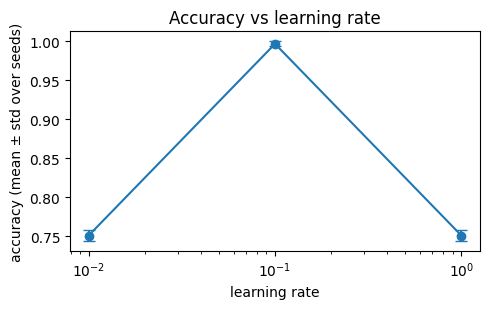

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 3.2))
ax.errorbar(
    ds["lr"].values, mean_acc.values, yerr=std_acc.values, marker="o", capsize=4
)
ax.set_xscale("log")
ax.set_xlabel("learning rate")
ax.set_ylabel("accuracy (mean ± std over seeds)")
ax.set_title("Accuracy vs learning rate")
fig.tight_layout()
plt.show()

## Save & reload

The dataset is self-contained — metrics plus per-run provenance in `ds.attrs`.
Persist it to netCDF (`pip install "mushin-py[netcdf]"`) and read it back
anywhere, no live sweep required.

In [ ]:
import xarray as xr

path = tempfile.mktemp(suffix=".nc")
ds.to_netcdf(path)
reloaded = xr.open_dataset(path)
reloaded["accuracy"].mean("seed")

<xarray.DataArray 'accuracy' (lr: 3)> Size: 24B
array([0.75086392, 0.99686164, 0.75086392])
Coordinates:
  * lr       (lr) float64 24B 0.01 0.1 1.0

**See also**

- [Workflows & sweeps guide](../guides/workflows.md) — building the sweep.
- [Notebook 01 — Sweeps → datasets](01_sweep_to_dataset.ipynb) — the sweep this
  analyzes, end to end.